# Notebook 12 – Artificial Neural Network for Tabular Data



## 1. What is an Artificial Neural Network?

An Artificial Neural Network is a machine learning model inspired by the way interconnected neurons process information.

An ANN is made of layers:

- **Input layer** – receives the features
- **Hidden layers** – learn patterns from the data
- **Output layer** – produces the final prediction

For a binary classification problem, the output can represent the probability of belonging to class 1.

### Real-world examples

ANNs can be used for:

- Customer churn prediction
- Fraud detection
- Loan default prediction
- Employee attrition prediction
- Disease classification
- Customer purchase prediction

### AI/ML usage

ANNs are useful when relationships between input features and the target may be complex or non-linear.

For tabular data, traditional models such as Logistic Regression, Decision Trees, and Gradient Boosting are also important. Therefore, it is useful to compare an ANN with a traditional model.


## 2. Understanding the problem

### Business question

Can we use a customer's previous purchase behavior to predict whether that customer will make another purchase in a future period?

### Target creation

I will use:

- **Observation period:** transactions before September 1, 2011
- **Future period:** transactions from September 1, 2011 onward

For each customer:

- `Churn = 0` → customer made a purchase in the future period
- `Churn = 1` → customer did not make a purchase in the future period

This creates a supervised binary classification problem.

### Why this is useful

A company can use a churn model to identify customers who may need retention campaigns, offers, reminders, or personalised communication.


## 3. Import required libraries

Libraries used:

- **Pandas** for data handling
- **NumPy** for numerical operations
- **Matplotlib** for visualisation
- **Scikit-learn** for preprocessing and Logistic Regression
- **PyTorch** for building and training the ANN
- **Seaborn** for the confusion matrix


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)


## 4. Load the data

The CSV file is read using `latin1` encoding because the uploaded retail dataset contains special characters in some text fields.


In [2]:
df = pd.read_csv("data.csv", encoding="latin1")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 5. Data inspection

Data inspection helps me understand:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic statistics

### AI/ML usage

Good data inspection is important because machine learning models learn directly from the data given to them. Incorrect data types, missing values, duplicates, or unusual values can affect model performance.


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [5]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("\nNumerical summary:")
display(df.describe())


Duplicate rows: 5268

Numerical summary:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 6. Understanding important columns

The important columns for this project are:

| Column | Meaning |
|---|---|
| InvoiceNo | Transaction/invoice number |
| StockCode | Product code |
| Description | Product description |
| Quantity | Number of items purchased |
| InvoiceDate | Date and time of transaction |
| UnitPrice | Price per item |
| CustomerID | Customer identifier |
| Country | Customer country |

For customer churn prediction, I need customer-level features rather than individual transaction-level rows.


## 7. Data preprocessing

Before creating customer features, I will:

1. Convert `InvoiceDate` into datetime format.
2. Remove rows without a CustomerID.
3. Remove cancelled invoices.
4. Remove invalid quantity and price values.

### Why preprocessing is needed

Machine learning models need clean and meaningful input data.

### Real-world example

A cancelled invoice should not be treated as a normal purchase when calculating customer buying behaviour.


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df = df.dropna(subset=["CustomerID"])

df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df = df[~df["InvoiceNo"].str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df.shape


(397884, 8)

## 8. Feature engineering

Feature engineering means creating useful input variables from raw data.

For this project, I will create customer-level **RFM features**.

### RFM

**Recency**
- How recently did the customer purchase?

**Frequency**
- How many transactions did the customer make?

**Monetary**
- How much money did the customer spend?

These features are commonly used for customer segmentation, customer value analysis, marketing analytics, and churn-related modelling.

### AI/ML usage

Feature engineering converts raw business data into variables that a model can use more effectively.


In [8]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

cutoff_date = pd.Timestamp("2011-09-01")

past_data = df[df["InvoiceDate"] < cutoff_date].copy()
future_data = df[df["InvoiceDate"] >= cutoff_date].copy()

reference_date = cutoff_date

rfm = past_data.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

rfm["Recency"] = (reference_date - rfm["LastPurchase"]).dt.days

rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,225,1,77183.60
1,12347.0,29,5,2790.86
2,12348.0,148,3,1487.24
3,12350.0,210,1,334.40
4,12352.0,162,5,1561.81


## 9. Create the churn target

Now I will check whether each customer purchased anything during the future period.

If the customer has no future transaction, the churn label is 1.

If the customer has at least one future transaction, the churn label is 0.

This is a useful example of creating a supervised learning target from raw business data.


In [9]:
future_customers = future_data["CustomerID"].unique()

rfm["Churn"] = (~rfm["CustomerID"].isin(future_customers)).astype(int)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,Churn
0,12346.0,225,1,77183.60,1
1,12347.0,29,5,2790.86,0
2,12348.0,148,3,1487.24,0
3,12350.0,210,1,334.40,1
4,12352.0,162,5,1561.81,0


In [10]:
print(rfm["Churn"].value_counts())
print("\nChurn percentage:")
print(rfm["Churn"].mean() * 100)


Churn
0    1952
1    1365
Name: count, dtype: int64

Churn percentage:
41.15164305094965


## 10. Check the engineered dataset

The final modelling dataset contains:

- Recency
- Frequency
- Monetary
- Churn

CustomerID is only an identifier, so it will not be used as a model feature.

### Why not use CustomerID?

CustomerID is an ID rather than a behavioural measurement. Giving an ID directly to a model usually does not provide meaningful predictive information.


In [11]:
model_df = rfm[["Recency", "Frequency", "Monetary", "Churn"]].copy()

model_df.describe()


,Recency,Frequency,Monetary,Churn
count,3317.000000,3317.000000,3317.000000,3317.000000
mean,92.142900,3.440760,1579.511776,0.411516
std,76.687522,5.586463,5976.600001,0.492183
min,0.000000,1.000000,2.900000,0.000000
25%,27.000000,1.000000,261.360000,0.000000
50%,72.000000,2.000000,555.650000,0.000000
75%,146.000000,4.000000,1355.110000,1.000000
max,273.000000,127.000000,176355.940000,1.000000


In [12]:
model_df.isnull().sum()


Recency      0
Frequency    0
Monetary     0
Churn        0
dtype: int64

## 11. Train/test split

A train/test split separates the data into:

- **Training data** – used to learn patterns
- **Testing data** – used to evaluate the final model

I will use 80% for training and 20% for testing.

`stratify=y` keeps the class distribution reasonably similar in both sets.

### AI/ML usage

A test set helps estimate how the model performs on data it has not seen during training.


In [13]:
X = model_df[["Recency", "Frequency", "Monetary"]].values
y = model_df["Churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 2653
Testing samples: 664


## 12. Feature scaling

The three features have very different numerical ranges.

For example:

- Recency may be measured in days
- Frequency may be a relatively small count
- Monetary may have much larger values

Standardization converts features to a similar scale.

### AI/ML usage

Scaling is especially important for neural networks because large differences in feature magnitude can make training less stable or slower.

The scaler is fitted only on training data to avoid data leakage.


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))


Training feature means:
[-9.08097988e-18  1.60549213e-16  5.96992040e-16]

Training feature standard deviations:
[1. 1. 1.]


## 13. Tensor conversion

PyTorch models work with tensors.

A tensor is a numerical data structure that can be processed efficiently by PyTorch.

### AI/ML usage

Tensors are the main data representation used by deep learning frameworks such as PyTorch.


In [15]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)


torch.Size([2653, 3])
torch.Size([2653, 1])


## 14. Create DataLoaders

A DataLoader sends training data to the model in smaller batches.

### Why use batches?

Instead of sending the complete dataset through the model at once, training can happen using small groups of samples.

This is called **mini-batch training**.

### AI/ML usage

Mini-batch training is commonly used in neural networks because it can make training more efficient and manageable.


In [16]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


## 15. ANN architecture

The ANN used here is intentionally simple.

### Architecture

**Input layer**
- 3 features

**Hidden layer 1**
- 16 neurons
- ReLU activation

**Hidden layer 2**
- 8 neurons
- ReLU activation

**Output layer**
- 1 neuron

The output will be used with `BCEWithLogitsLoss`.

### Why ReLU?

ReLU is a common activation function in neural networks. It introduces non-linearity so the network can learn more complex patterns than a purely linear model.

### Why one output neuron?

This is a binary classification problem, so one output value is enough to represent the model's score for the positive class.


### Simple view of the network

`3 input features → 16 neurons → 8 neurons → 1 output`

The network learns weights during training.




In [17]:
class ANNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

model = ANNModel()

print(model)


ANNModel(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


## 16. Loss function

The target has two classes:

- 0 = not churned
- 1 = churned

For binary classification, I will use **Binary Cross Entropy with Logits Loss**.

`BCEWithLogitsLoss` combines a sigmoid operation with binary cross-entropy loss in a numerically stable way.

### AI/ML usage

The loss function tells the model how different its predictions are from the actual target values.

During training, the model tries to reduce this loss.


In [18]:
criterion = nn.BCEWithLogitsLoss()


## 17. Optimizer

I will use the **Adam optimizer**.

Adam updates the model weights using gradients calculated during backpropagation.

### AI/ML usage

An optimizer controls how the model learns from its errors.

Adam is widely used for neural network training because it generally works well with a variety of problems and requires relatively little manual tuning for a basic model.


In [19]:
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 18. Training the ANN

The training process follows this cycle:

1. Take a batch of data
2. Perform a forward pass
3. Calculate the loss
4. Calculate gradients using backpropagation
5. Update the weights
6. Repeat for multiple epochs

### What is an epoch?

One epoch means the model has gone through the complete training dataset once.

I will also keep a validation split from the training data to monitor performance while learning.


In [20]:
from sklearn.model_selection import train_test_split

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

X_train_part_tensor = torch.tensor(X_train_part, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

y_train_part_tensor = torch.tensor(y_train_part, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_part_tensor, y_train_part_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


In [21]:
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}")


Epoch 10/50 - Train Loss: 0.5872 - Validation Loss: 0.6010
Epoch 20/50 - Train Loss: 0.5796 - Validation Loss: 0.5944
Epoch 30/50 - Train Loss: 0.5754 - Validation Loss: 0.5877
Epoch 40/50 - Train Loss: 0.5733 - Validation Loss: 0.5840
Epoch 50/50 - Train Loss: 0.5725 - Validation Loss: 0.5814


## 19. Training and validation loss

The loss curve helps me understand whether the model is learning.

- Training loss shows error on training data.
- Validation loss shows error on unseen validation data.

If training loss decreases while validation loss keeps increasing, it can be a sign of overfitting.


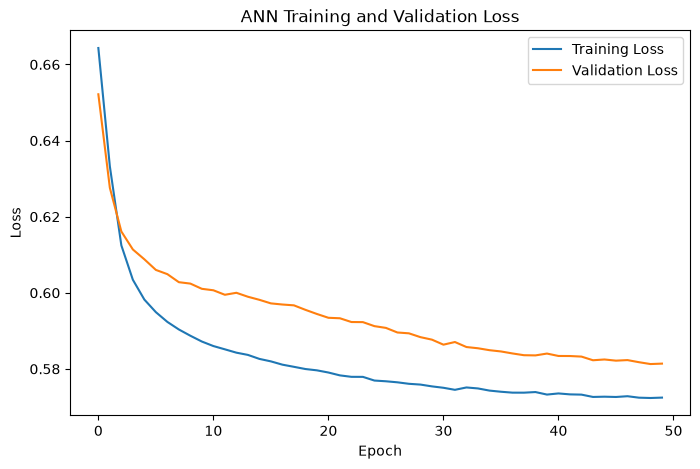

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.show()


## 20. Prediction

The ANN produces logits.

I will apply the sigmoid function to convert logits into probabilities between 0 and 1.

Then I will use 0.5 as the classification threshold:

- Probability >= 0.5 → class 1
- Probability < 0.5 → class 0

### AI/ML usage

Probability scores are useful when a business wants to choose a decision threshold based on the cost of false positives and false negatives.


In [23]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test_logits).numpy().ravel()

y_pred_ann = (test_probabilities >= 0.5).astype(int)

print("First 10 probabilities:")
print(test_probabilities[:10])

print("\nFirst 10 predictions:")
print(y_pred_ann[:10])


First 10 probabilities:
[2.2558554e-04 4.0542521e-02 4.6206972e-01 6.9735698e-02 1.1580824e-01
 6.3584501e-01 6.3584501e-01 4.0541205e-01 6.1246920e-01 5.9123623e-01]

First 10 predictions:
[0 0 0 0 0 1 1 0 1 1]


## 21. ANN evaluation

For classification, I will calculate:

### Accuracy

Percentage of all predictions that are correct.

### Precision

Among customers predicted as churned, how many were actually churned?

### Recall

Among customers who actually churned, how many were correctly identified?

### F1-score

A combined measure based on precision and recall.

### Confusion Matrix

Shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

### ROC-AUC

Measures how well the model separates the two classes across different probability thresholds.

For a churn problem, recall can be especially informative because missing a customer who actually churns may matter to a retention team. However, the useful metric depends on the business cost of different errors.


In [24]:
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann, zero_division=0)
ann_recall = recall_score(y_test, y_pred_ann, zero_division=0)
ann_f1 = f1_score(y_test, y_pred_ann, zero_division=0)
ann_auc = roc_auc_score(y_test, test_probabilities)

print("ANN Accuracy :", round(ann_accuracy, 4))
print("ANN Precision:", round(ann_precision, 4))
print("ANN Recall   :", round(ann_recall, 4))
print("ANN F1-score :", round(ann_f1, 4))
print("ANN ROC-AUC  :", round(ann_auc, 4))


ANN Accuracy : 0.6596
ANN Precision: 0.5786
ANN Recall   : 0.6337
ANN F1-score : 0.6049
ANN ROC-AUC  : 0.7387


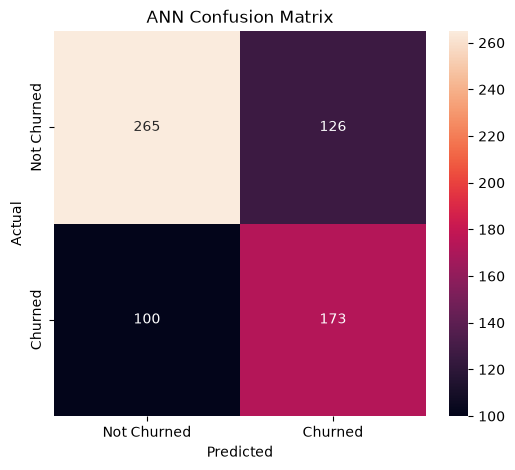

In [25]:
ann_cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 5))
sns.heatmap(
    ann_cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Churned", "Churned"],
    yticklabels=["Not Churned", "Churned"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.show()


## 22. Logistic Regression

Now I will build a traditional machine learning model using the same training and testing data.

Logistic Regression is a linear classification algorithm.

### Why compare it with ANN?

This gives a useful baseline.

If the ANN does not improve the results substantially, the simpler model may still be useful because it is easier to understand and usually requires fewer computational resources.

### AI/ML usage

Logistic Regression is widely used for:

- Customer churn
- Credit risk
- Medical classification
- Marketing response prediction
- Binary business decisions


In [26]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic = (logistic_probabilities >= 0.5).astype(int)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

print("Logistic Regression Accuracy :", round(logistic_accuracy, 4))
print("Logistic Regression Precision:", round(logistic_precision, 4))
print("Logistic Regression Recall   :", round(logistic_recall, 4))
print("Logistic Regression F1-score :", round(logistic_f1, 4))
print("Logistic Regression ROC-AUC  :", round(logistic_auc, 4))


Logistic Regression Accuracy : 0.6551
Logistic Regression Precision: 0.5894
Logistic Regression Recall   : 0.5311
Logistic Regression F1-score : 0.5588
Logistic Regression ROC-AUC  : 0.7327


## 23. Compare ANN and Logistic Regression

Both models were evaluated on the same test data.

| Metric | ANN | Logistic Regression |
|---|---:|---:|
| Accuracy | Calculated above | Calculated above |
| Precision | Calculated above | Calculated above |
| Recall | Calculated above | Calculated above |
| F1-score | Calculated above | Calculated above |
| ROC-AUC | Calculated above | Calculated above |

The values are generated when the notebook is executed.

### How to interpret the comparison

Instead of looking only at accuracy, I should consider precision, recall, F1-score, and ROC-AUC.

For a churn problem, the most useful metric depends on the business objective. For example, a company focused on finding as many potential churners as possible may pay more attention to recall.


In [27]:
comparison = pd.DataFrame({
    "Model": ["ANN", "Logistic Regression"],
    "Accuracy": [ann_accuracy, logistic_accuracy],
    "Precision": [ann_precision, logistic_precision],
    "Recall": [ann_recall, logistic_recall],
    "F1-score": [ann_f1, logistic_f1],
    "ROC-AUC": [ann_auc, logistic_auc]
})

comparison


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,ANN,0.659639,0.578595,0.633700,0.604895,0.738662
1,Logistic Regression,0.655120,0.589431,0.531136,0.558767,0.732666


## 24. Training time

Training time is another practical factor.

An ANN has multiple layers and learns many weights through iterative optimization.

Logistic Regression has a simpler mathematical structure.

I will measure the training time of both models in a fresh run.


In [28]:
import time

start = time.perf_counter()

timed_logistic = LogisticRegression(max_iter=1000, random_state=42)
timed_logistic.fit(X_train_scaled, y_train)

logistic_time = time.perf_counter() - start

start = time.perf_counter()

timed_ann = ANNModel()
timed_optimizer = optim.Adam(timed_ann.parameters(), lr=0.001)

for epoch in range(20):
    timed_ann.train()

    for X_batch, y_batch in train_loader:
        timed_optimizer.zero_grad()
        outputs = timed_ann(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        timed_optimizer.step()

ann_time = time.perf_counter() - start

print("Logistic Regression training time:", round(logistic_time, 4), "seconds")
print("ANN training time:", round(ann_time, 4), "seconds")


Logistic Regression training time: 0.012 seconds
ANN training time: 5.3455 seconds


## 25. ANN vs Logistic Regression – practical differences

### Performance

The metrics above show how the two models performed on this particular test set.

### Training time

Logistic Regression generally has a simpler training process. ANN training uses repeated forward passes, backpropagation, and weight updates.

The actual time depends on the hardware, dataset size, batch size, number of epochs, and model architecture.

### Complexity

**Logistic Regression**
- Simple model
- Few parameters for this dataset
- Fast to train
- Easier to implement

**ANN**
- Multiple layers and weights
- More hyperparameters
- Training requires more steps
- Can model non-linear relationships

### Interpretability

Logistic Regression is generally easier to interpret because its coefficients can be examined.

An ANN can be harder to explain because information is distributed across multiple learned weights.

### Dataset size

A small tabular dataset does not automatically require a neural network.

ANNs can become more useful when there is enough data and the problem contains patterns that a simpler model cannot capture well.

### Resource requirements

ANNs can require more computational resources, especially as the number of rows, features, layers, neurons, and training epochs increases.

For this project, the ANN is intentionally small because the goal is to understand the complete workflow rather than build a highly complex production model.
